Lugo Avalos Vanessa Aidee 6AM1 

1. Se carga el conjunto de caras de Olivetti
2. Se clasifica el conjunto de datos con 3 algoritmos diferentes (Naive Bayes, Análisis de discriminante lineal)
3. Se aplica reducción con LDA y se realiza la clasificación con los 3 algoritmos del paso anterior
4. Se imprime reporte se calsificación y matriz de confusión
5. Se carga una nueva imagen para clasificarla

# Librerías
Se importan las librerías necesarias para la práctica, se usa numpy para manipulación de arreglos, matplotlib y seaborn para visualizaciones, skleaarn para descargar los datos, dividir el conjunto de entrenamiento, aplicar análisis de componentes principales, análisis de discriminante lineal, naive bayes, obtener métricas, y se usa pil para abrir, manipular y guardar imagenes en varios formatos, finalmente se importa os que permite automatizar tareas interactuando con el sistema operativo.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from PIL import Image
import os

# Carga del conjunto de datos

In [35]:
data = fetch_olivetti_faces()
X = data.data
y = data.target
print(f'Forma de los datos: {X.shape}')
print(f'Cantidad de clases: {len(np.unique(y))}')

Forma de los datos: (400, 4096)
Cantidad de clases: 40


# Visualizar parte del conjunto de datos 
Se visualizan las primeras 10 imagenes usando un ciclo for para recorrer cada una indicando la escala de color y la clase a la que correspoonde la imagen. Se va cambiando la escala de color para identificar patrones.

<function matplotlib.pyplot.show(close=None, block=None)>

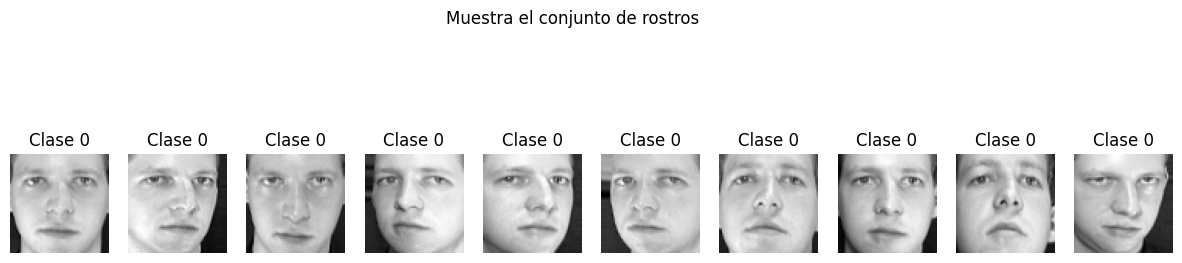

In [36]:
fig, axes = plt.subplots(1, 10, figsize = (15, 4)) #Se establece 1 fila con 10 imagenes
for i, ax in enumerate(axes): #Se hace ciclo for para recorrer cada imagen
    ax.imshow(data.images[i], cmap = 'gray') #Se carga la imagen y se le asigna la escala de color gris
    ax.set_title(f'Clase {y[i]}') #Se dice a que clase pertence cada persona
    ax.axis('off') #Se ocultan los ejes
plt.suptitle('Muestra el conjunto de rostros') #Se agrega un título en la parte superior
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

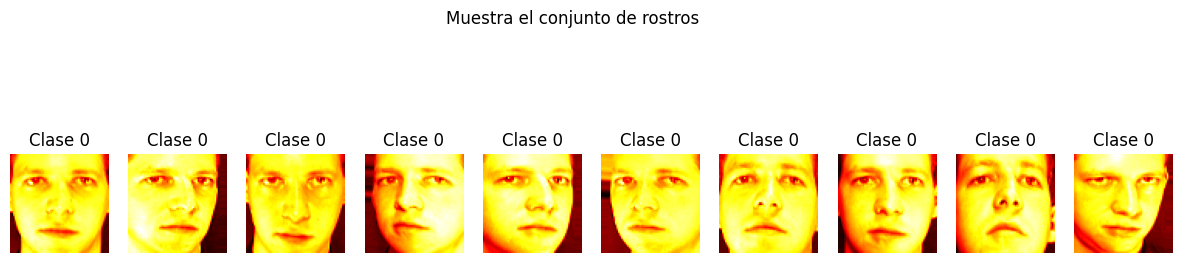

In [37]:
fig, axes = plt.subplots(1, 10, figsize = (15, 4))
for i, ax in enumerate(axes):
    ax.imshow(data.images[i], cmap = 'hot') #Se cambia la escala de color a tonos naranjas
    ax.set_title(f'Clase {y[i]}')
    ax.axis('off')
plt.suptitle('Muestra el conjunto de rostros')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

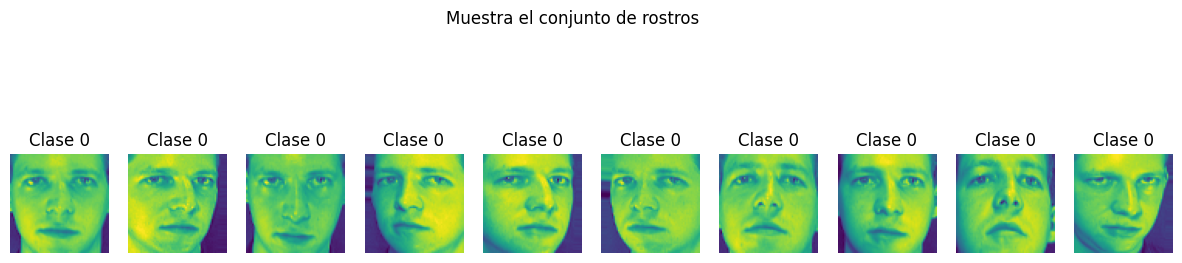

In [38]:
fig, axes = plt.subplots(1, 10, figsize = (15, 4))
for i, ax in enumerate(axes):
    ax.imshow(data.images[i], cmap = 'viridis') #Se cambia la escala de color a todos verdes
    ax.set_title(f'Clase {y[i]}')
    ax.axis('off')
plt.suptitle('Muestra el conjunto de rostros')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

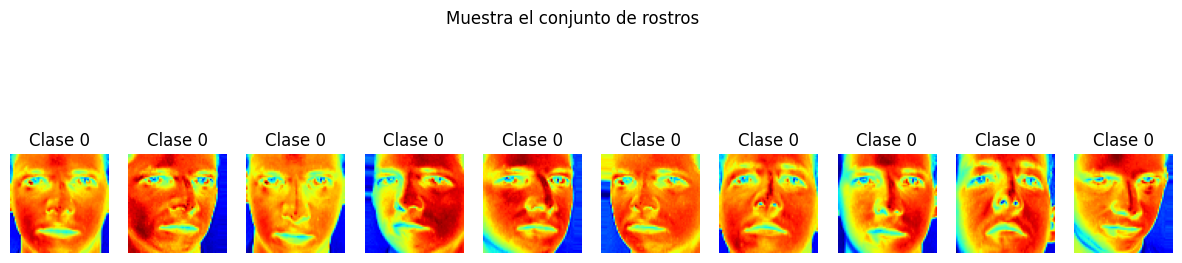

In [39]:
fig, axes = plt.subplots(1, 10, figsize = (15, 4))
for i, ax in enumerate(axes):
    ax.imshow(data.images[i], cmap = 'jet') #Se cambia la escala de color con tonos de mapa de calor
    ax.set_title(f'Clase {y[i]}')
    ax.axis('off')
plt.suptitle('Muestra el conjunto de rostros')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

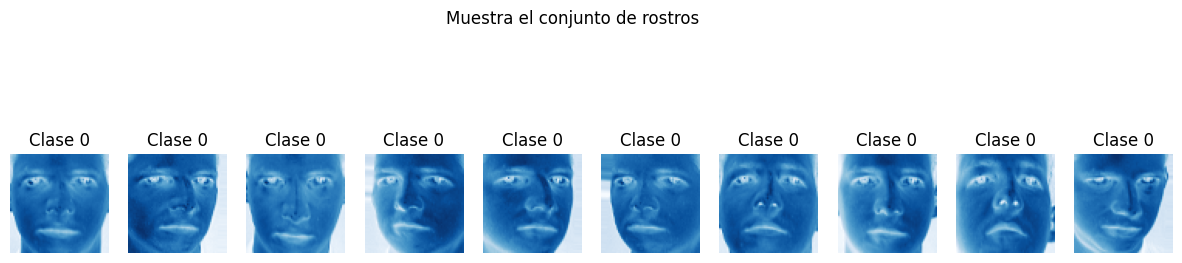

In [40]:
fig, axes = plt.subplots(1, 10, figsize = (15, 4))
for i, ax in enumerate(axes):
    ax.imshow(data.images[i], cmap = 'Blues') #Se cambia la escala de color a tonos azules
    ax.set_title(f'Clase {y[i]}')
    ax.axis('off')
plt.suptitle('Muestra el conjunto de rostros')
plt.show

# Mostrar una imagen por clase
Se crea una gráfica que muestra un ejemplo de cada clase, teniendo un total de 40 clases, se puede establecer que esta clasificación se hace de acuerdo a las características faciales de las personas

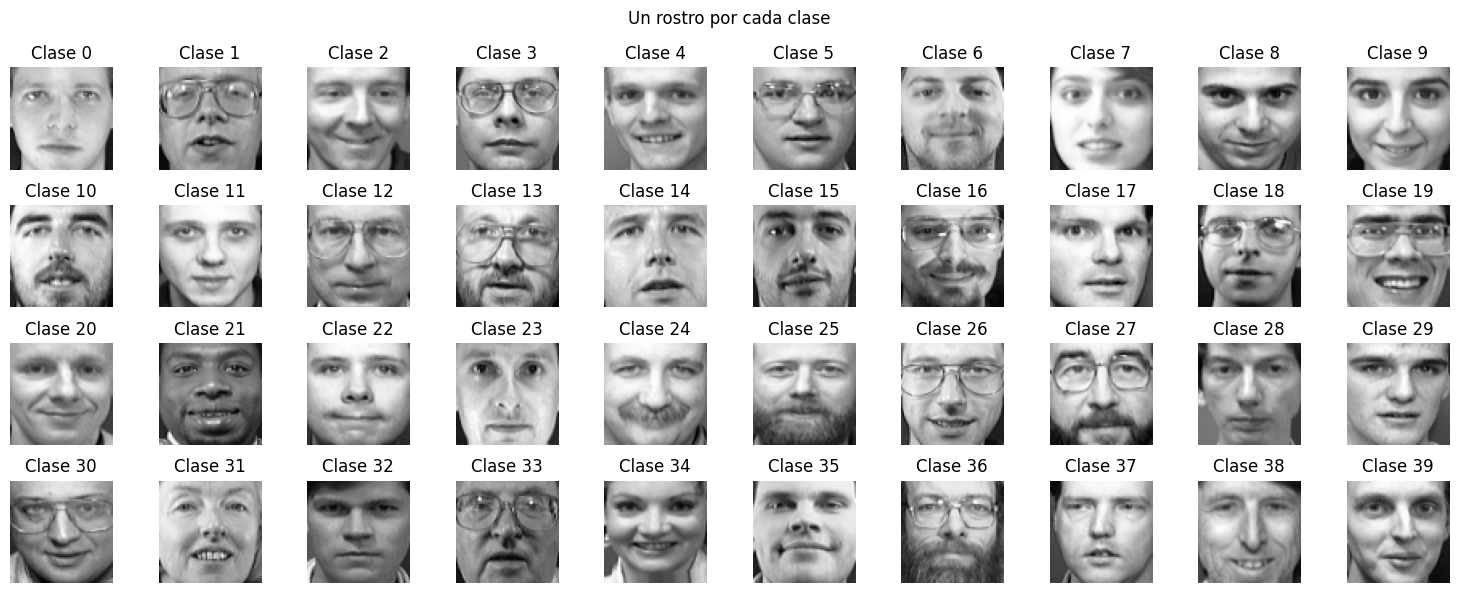

In [41]:
clases_unicas = np.unique(y) #Se obtienen las clases 
fig, axes = plt.subplots(4, 10, figsize = (15, 6)) #Se hace una gráfica de 4 filas x 10 columnas
for i, label in enumerate(clases_unicas): #Ciclo for para recorrer cada clase 
    img_index = np.where(y == label)[0][0] #Se guarda la primera imagen de cada clase
    ax = axes[i // 10, i % 10] #Se calcula en que parte de la gráfica debe ir la imagen
    ax.imshow(data.images[img_index], cmap = 'gray') #Se muestra la imagen en escala gris
    ax.set_title(f"Clase {label}") #Se escribe la clase a la que corresponde la imagen
    ax.axis('off') #Se ocultan los ejes
plt.suptitle("Un rostro por cada clase")
plt.tight_layout()
plt.show()

# División del conjunto de entrenamiento y prueba
Se hace la división del conjunto de entrenamiento 70% y el conjunto de prueba con 30% de los datos, se establece una semilla aleatoria de valor 7, y se aplica stratify = y, lo cual asegura que la proporción de las clases del conjunto de entrenamiento y de prueba sea la misma que el conjunto original aunque haya un desbalance de estas clases.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 7, stratify = y)

# Clasificación sin reducción
Se aplican algoritmos de clasifiación: Naive bayes,  análisis de discriminante (LDA) y árbol de decisión.

## Naive Bayes
Se trata de un algoritmo de clasificaición que predice la clase con probabilidades basado en el teorema de Bayes:
$$p(y/X) = \frac{P(X/y)\dot p(y)}{p(X)}$$
Donde las y predichas se obtienen como: 
$$\hat{y} = \arg\max_{y} P(y) \cdot \prod_{i=1}^{n} P(x_i | y)$$

### Métricas
Precisión: Mide que tan preciso es el modelo al hacer predicciones positivas.
$$Precision=\frac{True Positive}{True Positive + False Positive}$$
True Positive: Casos correctamente clasificados como positivos.    
False Positive: Casos incorrectamente clasificados como positivos.    
Sensibilidad o exhaustividad (Recall): Mide qué porcentaje de los casos positivos fueron detectados correctamente.   
$$Recall = \frac{True Positive}{True Positive + False Negatives}$$
False Negative: Casos positivos en que el modelo clasificó como negativos.   
F1- Score: Métrica combinada que busca equilibrar la presición y el recall.  
$$F1 = 2(\frac{(Precision)(Recall)}{(Precision + Recall)})$$
Suport: Indica el número de instancias reales de cada clase en los datos de prueba.

In [43]:
modelo_base = GaussianNB() #Se manda a llamar la clase de Naive Bayes
modelo_base.fit(X_train, y_train) #Se entrena el modelo
y_pred_base = modelo_base.predict(X_test) #Se obtienen las y predichas

print("Precisión sin reducción:", accuracy_score(y_test, y_pred_base)) #Se obtiene la precisión del modelo
print(classification_report(y_test, y_pred_base)) #Se obtiene el reporte de clasificación

Precisión sin reducción: 0.8583333333333333
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      1.00      1.00         3
           2       0.67      0.67      0.67         3
           3       0.50      0.67      0.57         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         3
           9       1.00      0.67      0.80         3
          10       1.00      0.67      0.80         3
          11       1.00      1.00      1.00         3
          12       0.67      0.67      0.67         3
          13       1.00      0.67      0.80         3
          14       1.00      1.00      1.00         3
          15       0.75      1.00      0.86         3
          16       0.75      1.00    

C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

## Análisis de discriminante lineal
Técnica de reducción de dimensionalidad donde se establece un centroide y un radio

In [44]:
lda = LinearDiscriminantAnalysis() #Se establece la clase para LDA
X_lda = lda.fit_transform(X, y) #Se entrena el modelo
y_pred_lda = lda.predict(X_test) #Se obtienen las y predichas

print("Precisión sin reducción:", accuracy_score(y_test, y_pred_lda)) #Se obtiene la precisión del modelo
print(classification_report(y_test, y_pred_lda)) #Se obtiene el reporte de clasificación

Precisión sin reducción: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      1.00      1.00         

## Árbol de decisión 
Los árboles de desición estan basados en reglas para aproximizar relaciones en datos estructurados. Se utiliza el criterio Gini por default.
#### Criterio Gini
Revisa la frecuencia con la que una muestra aleatoria se etiquetaria de manera incorrecta si se asignara por probabilidad de clase. Es el cirterio que usa por defecto sklearn
$$Gini = 1 -\sum_{i=1}^n p_ilog_2(p_i)$$
$p_i$: Probabilidad de la clase
Entre menor sea el valor del nodo, entonces los nodos son más homogéneos.

In [45]:
clf = DecisionTreeClassifier(max_depth= 10, random_state=42) #Clase del árbol de decisión
clf.fit(X_train, y_train) #Entrenamiento del árbol
y_pred_ar = clf.predict(X_test) # y predichas

print("Precisión sin reducción:", accuracy_score(y_test, y_pred_ar)) #Se obtiene la precisión del modelo
print(classification_report(y_test, y_pred_ar)) #Se obtiene el reporte de clasificación

Precisión sin reducción: 0.23333333333333334
              precision    recall  f1-score   support

           0       0.03      1.00      0.07         3
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           5       0.75      1.00      0.86         3
           6       0.50      0.67      0.57         3
           7       1.00      0.67      0.80         3
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         3
          10       0.50      0.67      0.57         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00         3
          14       0.00      0.00      0.00         3
          15       0.00      0.00      0.00         3
          16       0.00      0.00   

C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

# Análisis de componentes principales PCA

In [46]:
pca = PCA(n_components=150, whiten=True).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# Clasificación con reducción

## Naive Bayes

In [47]:
modelo_base = GaussianNB() #Se manda a llamar la clase de Naive Bayes
modelo_base.fit(X_train_pca, y_train) #Se entrena el modelo
y_pred_base_pca = modelo_base.predict(X_test_pca) #Se obtienen las y predichas

print("Precisión con reducción:", accuracy_score(y_test, y_pred_base_pca)) #Se obtiene la precisión del modelo
print(classification_report(y_test, y_pred_base_pca)) #Se obtiene el reporte de clasificación

Precisión sin reducción: 0.8666666666666667
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       1.00      1.00      1.00         3
           2       0.50      0.67      0.57         3
           3       1.00      0.67      0.80         3
           4       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       1.00      0.67      0.80         3
           7       0.25      1.00      0.40         3
           8       1.00      1.00      1.00         3
           9       1.00      0.67      0.80         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      0.67      0.80         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.50      1.00      0.67         3
          16       1.00      1.00    

C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

## Análisis de discriminante lineal

In [53]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_pca, y_train)
y_pred_lda = lda.predict(X_test_pca)

print("Precisión LDA con reducción:", accuracy_score(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

Precisión LDA con PCA: 0.9916666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       0.75      1.00      0.86         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      1.00      

## Árbol de decisión

In [50]:
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)
y_pred_ar_pca = clf.predict(X_test_pca) # y predichas

print("Precisión con reducción:", accuracy_score(y_test, y_pred_ar_pca)) #Se obtiene la precisión del modelo
print(classification_report(y_test, y_pred_ar_pca)) #Se obtiene el reporte de clasificación

Precisión sin reducción: 0.38333333333333336
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.67      0.67      0.67         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           5       1.00      0.67      0.80         3
           6       0.20      0.33      0.25         3
           7       0.75      1.00      0.86         3
           8       0.00      0.00      0.00         3
           9       1.00      0.67      0.80         3
          10       1.00      0.67      0.80         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         3
          13       1.00      1.00      1.00         3
          14       0.08      1.00      0.14         3
          15       0.29      0.67      0.40         3
          16       0.50      0.33   

C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\venss\Documents\ESCOM\6_Semestre\AVD\unidad1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

# Nueva imagen
Se carga una nueva imagen para predecir su clasificación, se le aplica pca y lda

La clase predicha por el modelo (PCA + LDA) es: 7


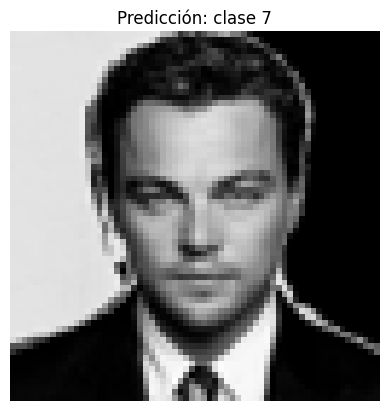

In [57]:
ruta_imagen = "cara.png"

imagen = Image.open(ruta_imagen).convert('L').resize((64, 64)) 
imagen_vector = np.asarray(imagen, dtype=np.float32).flatten() / 255.0

imagen_pca = pca.transform([imagen_vector]) #Se aplica análisis de componentes principales
imagen_lda = lda.transform(imagen_pca) #Se aplica análisis de discriminante lineal

X_train_lda = lda.transform(X_train_pca)
X_test_lda = lda.transform(X_test_pca)

modelo_lda = DecisionTreeClassifier(max_depth=10, random_state=42)
modelo_lda.fit(X_train_lda, y_train)

prediccion = modelo_lda.predict(imagen_lda) #Se usa el modelo de LDA

print(f"La clase predicha por el modelo (PCA + LDA) es: {prediccion[0]}")

plt.imshow(imagen, cmap='gray')
plt.title(f"Predicción: clase {prediccion[0]}")
plt.axis('off')
plt.show()

# Conclusión 
Para conclluir, el algoritmo de Nive Bayes aumentó de precisión después de aplicar reducción de dimensión mediante el análisis de componentes principales, para el caso de análisis de discriminante lineal se tuvo mayor precisión antes de aplicar pca, y para el árbol de decisión se tuvo mayor precisión después de aplica pca, sin embargo, el árbol de decisión realiza una mala clasificación, lo cual puede ser debido al tamaño de su profundidad. Finalmente, se cargo una imagen y obtuvo que pertenece a la clase 7.